In [1]:
import os
# Set environment variable to avoid KMP duplicate library error
# This is a workaround for some systems where the KMP (Intel's OpenMP) library 
# might be loaded multiple times, causing a runtime error.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from swotted import fastSWoTTeDModule, fastSWoTTeDTrainer, fastSWoTTeDDataset
from swotted.utils import Subset, success_rate
from swotted.loss_metrics import *

from omegaconf import OmegaConf
# from tests.gen_data import gen_synthetic_data
from torch.utils.data import DataLoader

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import numpy as np
import os

# First run using a simulated tensor

We present here a simple example to show the basic functionalities. It uses a random input tensor, more complex examples can be explored in the other [notebook](02_swotted_demo_complex_tensor.ipynb).

We first generate a random tensor. Note that the tensor can be replaced by an irregular tensor (list of tensors of size $N\times T_k$ with $T_k$ that varies from one patient to the other).

In [2]:
K = 200  #: number of patients
N = 5  #: number of medical events
T = 10  #: length of time's stay
#generation of a random tensor
X=torch.bernoulli( torch.ones(K,N,T)*0.2 )

We now define the model. The configuration holds the main parameters of `SWoTTeD`.  It uses [OmegaConf](https://omegaconf.readthedocs.io) configuration to ease the use of the dictionaries.

The SWoTTeD module is implemented as [PyTorch Lightning](https://lightning.ai/) module, and it has to be used with the corresponding trainer. Indeed, SWoTTeD optimisation problem is a not a classical supervised task and the optimization problem has to be set with the knowledge of the size of the dataset.

In [3]:
params = {}
params["model"] = {}
params["model"]["non_succession"] = 0.5
params["model"]["sparsity"] = 0.5
params["model"]["rank"] = 4  #: number of phenotypes to discover
params["model"]["twl"] = 3  #: length of time's window
params["model"]["N"] = N
params["model"]["metric"] = "Bernoulli"
params["training"] = {}
params["training"]["batch_size"] = 40
params["training"]["nepochs"] = 100
params["training"]["lr"] = 1e-2
params["predict"] = {}
params["predict"]["nepochs"] = 100
params["predict"]["lr"] = 1e-2

config = OmegaConf.create(params)

# define the model
swotted = fastSWoTTeDModule(config)

train_loader = DataLoader(
    fastSWoTTeDDataset(X),
    batch_size=params["training"]["batch_size"],
    shuffle=False,
    collate_fn=lambda x: x,
)

# train the model
trainer = fastSWoTTeDTrainer(
    max_epochs=params["training"]["nepochs"]
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Then, we run the training of the model.

In [4]:
trainer.fit(model=swotted, train_dataloaders=train_loader)

c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | model        | SlidingWindowConv | 0      | train
  | other params | n/a               | 60     | n/a  
-----------------------------------------------------------
60        Trainable params
0         Non-trainable params
60        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve perfo

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


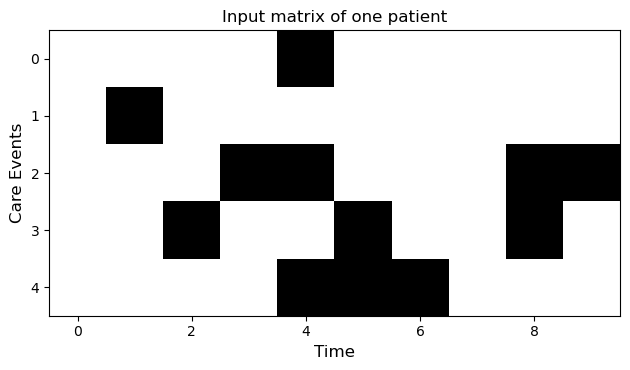

In [12]:
id = 20

fig, axs = plt.subplots()
axs.imshow(X[id], vmin=0, vmax=1, cmap="binary", interpolation='none')
axs.set_title("Input matrix of one patient", fontsize=12) 
axs.set_xlabel("Time", fontsize=12)
axs.set_ylabel("Care Events", fontsize=12)
axs.set_xticks(np.arange(0, T, 2)) 
axs.set_yticks(range(X[id].shape[0]))
plt.tight_layout()
plt.show()

Finally we can explore the results: 
* visualize the discovered phenotypes
* make reconstruction of input tensors
* ... 

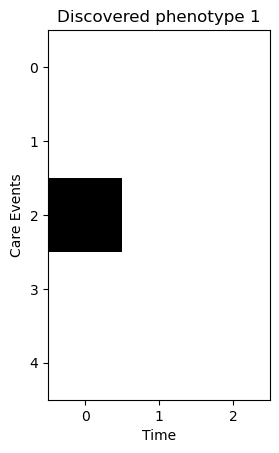

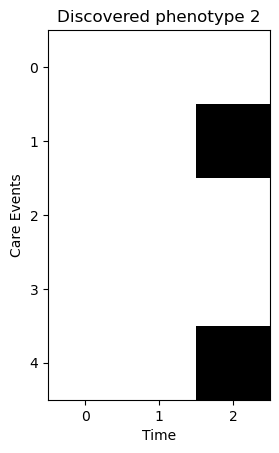

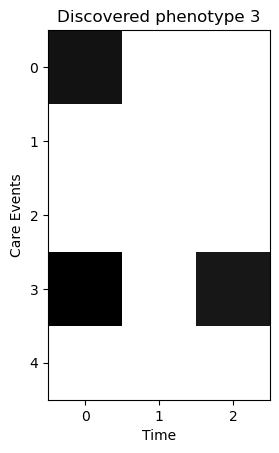

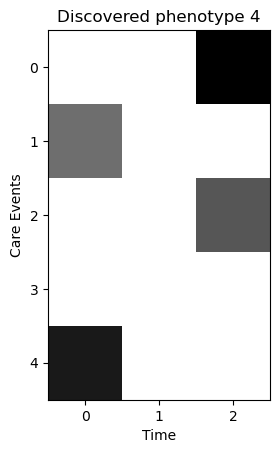

In [7]:
# visualize the phenotypes
Ph = swotted.Ph.flip(2).detach().numpy()

for i in range(params["model"]["rank"]):
    plt.imshow(Ph[i], vmin=0, vmax=1, cmap="binary",interpolation='none')
    plt.ylabel("Care Events")
    plt.xlabel("Time")
    plt.title(f"Discovered phenotype {i + 1}")
    plt.show()

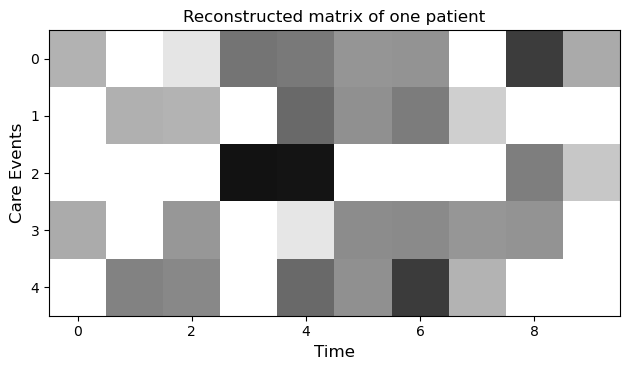

In [ ]:
# make decomposition with the train model: it projects the X on the phenotypes of the model
# note that projection can be applied on new data. We use data from the training set for the sake
# of simplicity
W = swotted(X[id, :, :].unsqueeze(0))
# Apply reconstruction
Y = swotted.model.reconstruct(W,swotted.Ph)

# Patient decomposition
fig, axs = plt.subplots()
axs.imshow(Y[0].detach().numpy(), vmin=0, vmax=1, cmap="binary", interpolation='none')
axs.set_title("Reconstructed matrix of one patient", fontsize=12) 
axs.set_xlabel("Time", fontsize=12)
axs.set_ylabel("Care Events", fontsize=12)
axs.set_xticks(np.arange(0, T, 2)) 
axs.set_yticks(range(X[id].shape[0]))
plt.tight_layout()
plt.show()

In [17]:
FITx = success_rate(X[id], Y[0])
print(f"FITx: {FITx:.2f}")

FITx: 0.24


*Mapping of X into the Phenotype Space*

The mapping of the input tensor `X` into the phenotype space is performed using the trained SWoTTeD model. This process involves projecting the input data onto the discovered phenotypes, which allows us to represent each patient's data in terms of the identified phenotypes.

The steps involved in this mapping are as follows:

1. **Projection**: The input tensor `X` is projected onto the phenotype space using the trained SWoTTeD model. This projection is done by passing the input tensor through the model, which results in a new tensor `W`. The tensor `W` represents the weights or contributions of each phenotype for each patient over time.

2. **Reconstruction**: The projected tensor `W` can be used to reconstruct the input tensor `X` using the discovered phenotypes. This reconstruction helps in understanding how well the phenotypes capture the underlying patterns in the input data.

The following code snippet demonstrates the projection of the input tensor `X` onto the phenotype space:


In [11]:
# Project the patients onto the phenotype space
W_all = swotted(X)
W_all.shape

torch.Size([200, 4, 8])

*Reshape the Tensor for Clustering*

In the next step, we need to reshape the tensor `W_all` to prepare it for clustering. The tensor `W_all` has the shape `(K, rank, T)`, where `K` is the number of patients, `rank` is the number of phenotypes, and `T` is the length of the time window.

To perform clustering, we need to convert this 3D tensor into a 2D array where each row represents a patient and each column represents a feature. We achieve this by reshaping `W_all` to have the shape `(K, rank * T)`. This way, each patient's data is flattened into a single row, making it suitable for clustering algorithms like KMeans.

In [12]:
# Reshape W_all for clustering
W_all_reshaped = W_all.view(K, -1).detach().numpy()
W_all_reshaped.shape

(200, 32)

In [13]:
from sklearn.cluster import KMeans

# Perform KMeans clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(W_all_reshaped)

# Get the cluster labels
labels = kmeans.labels_

# Print the cluster labels
print(labels)

c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 217, in _count_physical_cores
    raise ValueError(
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memor

[0 0 0 0 0 1 0 0 0 0 0 0 0 2 0 0 0 2 2 2 0 1 1 0 0 2 1 0 1 2 1 0 0 1 1 0 0
 1 0 2 1 1 0 2 0 0 0 1 2 2 0 2 0 0 2 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 2
 0 2 1 1 2 1 0 2 0 0 1 2 0 2 0 1 0 2 2 2 0 0 1 1 2 0 0 0 2 2 2 2 0 2 0 0 2
 2 1 0 1 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 2 0 1 2 0 0 1 0 0 1 0 1 0 2
 2 1 0 0 0 0 1 2 2 1 2 0 2 2 1 2 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0
 0 0 0 1 2 0 0 0 0 1 0 0 0 1 0]
